In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

# Load the clean data we saved in Phase 1
kerala = pd.read_csv("kerala_clean.csv")
print(f"Loaded: {kerala.shape}")
kerala.head()

Loaded: (115, 20)


,SUBDIVISION,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,FLOOD_RISK
0,KERALA,1901,28.7,44.7,51.6,160.0,174.7,824.6,743.0,357.5,197.7,266.9,350.8,48.4,3248.6,73.4,386.2,2122.8,666.1,High
1,KERALA,1902,6.7,2.6,57.3,83.9,134.5,390.9,1205.0,315.8,491.6,358.4,158.3,121.5,3326.6,9.3,275.7,2403.4,638.2,High
2,KERALA,1903,3.2,18.6,3.1,83.6,249.7,558.6,1022.5,420.2,341.8,354.1,157.0,59.0,3271.2,21.7,336.3,2343.0,570.1,High
3,KERALA,1904,23.7,3.0,32.2,71.5,235.7,1098.2,725.5,351.8,222.7,328.1,33.9,3.3,3129.7,26.7,339.4,2398.2,365.3,Medium
4,KERALA,1905,1.2,22.3,9.4,105.9,263.3,850.2,520.5,293.6,217.2,383.5,74.4,0.2,2741.6,23.4,378.5,1881.5,458.1,Medium


In [2]:
# Kerala has 4 meteorological seasons
# Each one behaves differently — model should know them separately

kerala["MONSOON"]     = kerala[["JUN","JUL","AUG","SEP"]].sum(axis=1)
kerala["PRE_MONSOON"] = kerala[["MAR","APR","MAY"]].sum(axis=1)
kerala["POST_MONSOON"]= kerala[["OCT","NOV"]].sum(axis=1)
kerala["WINTER"]      = kerala[["DEC","JAN","FEB"]].sum(axis=1)

# axis=1 means "sum across columns" (each row)
# axis=0 would mean "sum down rows" — wrong here

print("Season averages (mm):")
print(kerala[["MONSOON","PRE_MONSOON","POST_MONSOON","WINTER"]].mean().round(1))

Season averages (mm):
MONSOON         2022.9
PRE_MONSOON      377.3
POST_MONSOON     457.7
WINTER            67.7
dtype: float64


Average monsoon ratio: 68.98%
Min: 44.13%
Max: 84.04%


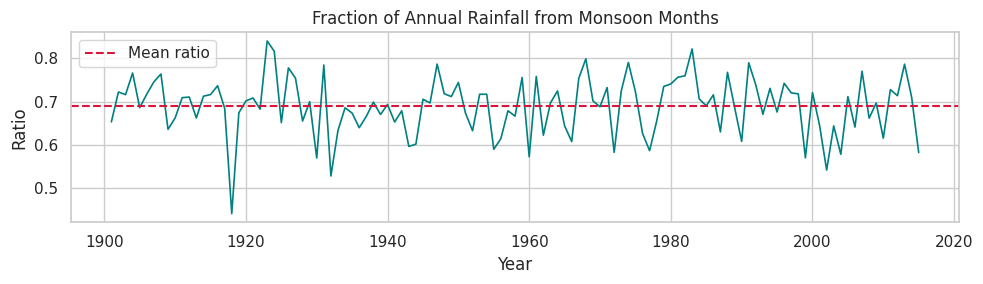

In [3]:
# What fraction of annual rain came from monsoon months?
# A ratio tells the model about rain DISTRIBUTION, not just total

kerala["MONSOON_RATIO"] = kerala["MONSOON"] / kerala["ANNUAL"]

print(f"Average monsoon ratio: {kerala['MONSOON_RATIO'].mean():.2%}")
print(f"Min: {kerala['MONSOON_RATIO'].min():.2%}")
print(f"Max: {kerala['MONSOON_RATIO'].max():.2%}")

# Plot it
plt.figure(figsize=(10, 3))
plt.plot(kerala["YEAR"], kerala["MONSOON_RATIO"], color="teal", linewidth=1.2)
plt.axhline(kerala["MONSOON_RATIO"].mean(), color="crimson",
            linestyle="--", label="Mean ratio")
plt.title("Fraction of Annual Rainfall from Monsoon Months")
plt.ylabel("Ratio")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# How far is each year from the long-term average?
# This is called "mean normalisation" — one of the most used techniques in ML

mean_annual = kerala["ANNUAL"].mean()
std_annual  = kerala["ANNUAL"].std()

# Z-score: (value - mean) / std
# A z-score of +2 means "2 standard deviations above average" = very wet year
kerala["RAIN_ANOMALY"] = (kerala["ANNUAL"] - mean_annual) / std_annual

print(f"Historical mean: {mean_annual:.1f} mm")
print(f"Standard deviation: {std_annual:.1f} mm")
print(f"\nTop 5 wettest years:")
print(kerala[["YEAR","ANNUAL","RAIN_ANOMALY"]].sort_values("RAIN_ANOMALY", ascending=False).head())

Historical mean: 2925.5 mm
Standard deviation: 422.1 mm

Top 5 wettest years:
    YEAR  ANNUAL  RAIN_ANOMALY
60  1961  4257.8      3.156299
23  1924  4226.4      3.081911
32  1933  4072.9      2.718264
58  1959  3746.0      1.943825
6   1907  3671.1      1.766384


In [5]:
# Was last year also a high rainfall year?
# .shift(1) moves the column DOWN by 1 row —
# so each row now sees the PREVIOUS year's value

kerala["PREV_YEAR_RAIN"] = kerala["ANNUAL"].shift(1)

# The first row will be NaN (no previous year) — fill with the mean
kerala["PREV_YEAR_RAIN"].fillna(kerala["ANNUAL"].mean(), inplace=True)

print(kerala[["YEAR","ANNUAL","PREV_YEAR_RAIN"]].head(8))

   YEAR  ANNUAL  PREV_YEAR_RAIN
0  1901  3248.6     2925.487826
1  1902  3326.6     3248.600000
2  1903  3271.2     3326.600000
3  1904  3129.7     3271.200000
4  1905  2741.6     3129.700000
5  1906  2708.0     2741.600000
6  1907  3671.1     2708.000000
7  1908  2648.3     3671.100000


/tmp/ipykernel_21347/3871781428.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  kerala["PREV_YEAR_RAIN"].fillna(kerala["ANNUAL"].mean(), inplace=True)


In [6]:
kerala.to_csv("kerala_features.csv", index=False)

print("Saved kerala_features.csv ✓")
print(f"\nNew shape: {kerala.shape}")
print(f"\nAll features: {kerala.columns.tolist()}")

Saved kerala_features.csv ✓

New shape: (115, 27)

All features: ['SUBDIVISION', 'YEAR', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'FLOOD_RISK', 'MONSOON', 'PRE_MONSOON', 'POST_MONSOON', 'WINTER', 'MONSOON_RATIO', 'RAIN_ANOMALY', 'PREV_YEAR_RAIN']
